# Overview


In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
from pandas.api.types import CategoricalDtype
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import discretized data
df = pd.read_pickle("../Data/DON_Heart_Data.pkl")
# display 
df.head()

,DeceasedRetyped_DON,AntigenDA1_DON,AntigenDA2_DON,AntigenDB1_DON,AntigenDB2_DON,AntigenDR1_DON,AntigenDR2_DON,Citizenship_DON,PastCocaineUse_DON,Age_DON,Ethnicity_DON,Hepatitis_B_CoreAntibody_DON,SurfaceAntigenHEP_B_DON,BloodGroup_DON,HeavyAlcoholUse_DON,Gender_DON,ResidencyState_DON,Antibody_HEP_C_DON,NonHeartBeating_DON,AntiHypertensive_DON,BloodInfectionSource_DON,BloodUreaNitrogenLevel_DON,Creatinine_DON,OtherInfectionSource_DON,Diuretics_DON,SteroidsUse_DON,TriiodothyronineT3_DON,ThyroxineT4_DON,OtherMedsText2_DON,OtherMedsText3_DON,OtherMedsText1_DON,PulmonaryInfection_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,TerminalTotalBilirubin_DON,UrineInfection_DON,Vasodilators_DON,AntibodyResultRPR_VDRL_DON,InfectionClinical_DON,CocaineUse_DON,OtherDrugUse_DON,CancerExtraCranial_DON,CancerSite_DON,CigaretteHistory_DON,HypertensionHistory_DON,CancerIntraCranial_DON,CancerHistory_DON,DiabetesHistory_DON,Diabetes_DON,PastOtherDrugUse_DON,CancerSkin_DON,SerologyAntiCMV_DON,CauseOfDeath_DON,SynthicAntiDiureticHormone_DON,DeathCircumstance_DON,DeathMechanism_DON,HeparinManagement_DON,ArginnieManagement_DON,InsulinManagement_DON,HeightCm_DON,WeightKg_DON,HBV_NAT_Result_DON,HCV_NAT_Result_DON,HIV_NAT_Result_DON,IschemicTimeHour_DON,AllocationType_DON,UrinePortein_DON,CardiacArrest_DON,LungPO2_DON,MyocardialInfarctionHistory_DON,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_DON,CoronaryAngiogram_DON,Biopsy_DON,Tatoos_DON,AntibodyResultHBSAB_DON,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,HIV_Risk_DON,InotropicAgent_DON,KidneyAllocation_DON,InotropicMedicationProcurement_DON,LT_ONE_WEEK_DON,TransfusionNumber_DON,LungPO2_Done_DON,LungPO2_FIO2_DON,OrganRecovery_PCO2_DON,PulmonaryCatheter_DON,BronchoscopyLeft_DON,BronchoscopyRight_DON,ChestXray_DON,BloodPH_DON,Hematocrit_DON,TransplantSurvivalDay
0,No,2,29,44,49,4,15,US Citizen,No,31.0,Black,Negative,Negative,A,No,M,CA,Negative,No,Yes,No,18.0,1.30,No,Yes,No,No,No,"KCL,","DOPAMINE, VASOPRESSIN,","ZOSYN, VANCOMYCIN",Yes,46.0,40.0,0.4,No,No,Negative,Yes,Missing,Missing,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,Yes,HOMICIDE,GUNSHOT WOUND,Yes,No,Yes,172.7,107.0,Missing,Missing,Missing,4.9,Local,No,No,182.0,No,Echo,60.0,No,Biopsy not done,Yes,Not Done,Positive,Negative,No,Missing,No,No,No,1 - 5,Yes,47.0,40.0,No,Normal,Normal,Abnormal-right,7.38,26.2,329.0
1,Yes,2,68,49,60,10,16,Non-US Citizen/US Resident,No,30.0,Hispanic,Negative,Negative,O,No,M,TX,Negative,No,No,No,29.0,0.70,No,Yes,No,No,Yes,NaN,NaN,"ANCEF, FENTANYL, VERSED,LASIX",Yes,38.0,171.0,0.8,No,No,Negative,Yes,Missing,Missing,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,No,"Accident, Non-MVA",BLUNT INJURY,Yes,Yes,No,172.7,67.1,Missing,Missing,Missing,3.1,Local,No,No,323.0,No,Echo,55.0,No,Biopsy not done,No,Not Done,Positive,Negative,No,Dopamine,No,Yes,No,6 - 10,Yes,100.0,28.0,No,Normal,Normal,Abnormal-left,7.50,27.8,2592.0
2,No,2,3,7,44,11,15,US Citizen,No,15.0,"White, Non-Hispanic",Negative,Negative,O,No,M,NY,Negative,No,No,No,15.0,0.74,No,Yes,Yes,No,Yes,"AMPHOTERICIN, BETADINE",ZANTAC,"ZOSYN, VANCOMYCIN",Yes,445.0,217.0,0.7,No,No,Negative,Yes,Missing,Yes,No,NO,No,No,No,No,No,No,Yes,No,Negative,ANOXIA,No,NONE OF THE ABOVE,DRUG INTOXICATION,Yes,Yes,No,170.0,59.0,Missing,Missing,Missing,1.4,Local,No,No,401.0,No,Echo,60.0,No,Biopsy not done,No,Not Done,Negative,Negative,No,"Other, specify",No,Yes,No,NONE,Yes,100.0,41.0,No,Normal,Missing,Abnormal-both,7.40,25.4,2913.0
3,Yes,33,68,39,51,1,8,US Citizen,No,47.0,"White, Non-Hispanic",Negative,Negative,A1,No,F,NY,Negative,No,Yes,Yes,29.0,1.34,No,Yes,Yes,No,Yes,"D50, DOPAMINE, DIFLUCAN",NaN,"KCL, VANCO, MAG, ZOSYN",Yes,248.0,165.0,0.3,Yes,No,Negative,Yes,Missing,Yes,No,"SKIN - SQUAMOUS, BASAL CELL",Yes,Yes,No,Yes,No,No,Yes,No,Positive,CEREBROVASCULAR/STROKE,No,DEATH FROM NATURAL CAUSES,INTRACRANIAL HEMORRHAGE/STROKE,Yes,Yes,Yes,163.0,115.2,Missing,Missing,Missing,3.5,Regional,Yes,No,267.0,No,Echo,60.0,"Yes, normal",Biopsy not done,Yes,Not Done,Positive,Negative,No,Missing,No

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28326 entries, 0 to 28750
Data columns (total 94 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   DeceasedRetyped_DON                 28326 non-null  category
 1   AntigenDA1_DON                      28326 non-null  category
 2   AntigenDA2_DON                      28326 non-null  category
 3   AntigenDB1_DON                      28326 non-null  category
 4   AntigenDB2_DON                      28326 non-null  category
 5   AntigenDR1_DON                      28326 non-null  category
 6   AntigenDR2_DON                      28326 non-null  category
 7   Citizenship_DON                     28326 non-null  category
 8   PastCocaineUse_DON                  28326 non-null  category
 9   Age_DON                             28326 non-null  float64 
 10  Ethnicity_DON                       28326 non-null  category
 11  Hepatitis_B_CoreAntibody_DON     

In [4]:
u.any_nans(df)

--- Missing Values Found (Total Rows: 28,326) ---
                                Count Percentage
OtherMedsText3_DON              11526   40.6905%
OtherMedsText2_DON               3670   12.9563%
OtherMedsText1_DON                589    2.0794%
IschemicTimeHour_DON              188    0.6637%
LungPO2_FIO2_DON                  171    0.6037%
LungPO2_DON                        93    0.3283%
OrganRecovery_PCO2_DON             82    0.2895%
BloodPH_DON                        76    0.2683%
Level_SGOT_AST_DON                 57    0.2012%
Level_SGOT_ALT_DON                 57    0.2012%
TerminalTotalBilirubin_DON         56    0.1977%
BloodUreaNitrogenLevel_DON         52    0.1836%
Creatinine_DON                     52    0.1836%
Hematocrit_DON                     52    0.1836%
LV_EjectionFractionPercent_DON     31    0.1094%
WeightKg_DON                        3    0.0106%


### Combine Meds

In [5]:
# select column name
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
cols = sorted(cols)
df[cols].sample(n=10, random_state=SEED)

,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
4570,"VECURONIUM,FENTANYL,UNASYN","DUONEB.NYSTATIN,NATURAL TEARS",NaN
20866,"ZOSYN, ROCURONIUM",ALBUTEROL,NaN
23163,"ANCEF,NOREPINEPHRINE,SODIUM BICARBONATE",NaN,NaN
17289,"ANCEF,FORTAZ,MAGNESIUM SULFATE,NEOSYNEPHRINE",NaN,NaN
18059,"VANC, CEFEPIME, FLAGYL",LEVOPHED NEO,"DOPAMINE, ROC"
25696,"NEOSYNEPHRINE, BICARB,","ANCEF, KCL, CAGL, KPHOS,","MAGSO4, VECURONIUM, ALBUTEROL EPHEDRINE"
10473,"ANCEF, LEVAQUIN","ROCURONIUM, FENTANYL",VECURONIUM
6565,DOPAMINE,ALBUTEROL,ANCEF
1,"ANCEF, FENTANYL, VERSED,LASIX",NaN,NaN
2025,"DEXTROSE, INVANZ, VANCOMYCIN","CALCIUM CHLORIDE, POTASSIUM PHOSPHATE","ZOSYN, ROCURONIUM"


In [6]:
df["Meds_DON"] = (
    df[cols].fillna("")
    .agg(", ".join, axis=1)

    # Normalize separators: convert ., /, ;, : to commas
    .str.replace(r"[./;:]", ",", regex=True)

    # Fix double commas
    .str.replace(r",\s*,", ",", regex=True)

    # Normalize comma spacing (remove spaces before/after)
    .str.replace(r"\s*,\s*", ", ", regex=True)

    # Strip trailing commas/spaces
    .str.strip(", ")
)
df["Meds_DON"].sample(n=10, random_state=SEED)

4570                               VECURONIUM, FENTANYL, UNASYN, DUONEB, NYSTATIN, NATURAL TEARS
20866                                                               ZOSYN, ROCURONIUM, ALBUTEROL
23163                                                  ANCEF, NOREPINEPHRINE, SODIUM BICARBONATE
17289                                            ANCEF, FORTAZ, MAGNESIUM SULFATE, NEOSYNEPHRINE
18059                                        VANC, CEFEPIME, FLAGYL, LEVOPHED NEO, DOPAMINE, ROC
25696    NEOSYNEPHRINE, BICARB, ANCEF, KCL, CAGL, KPHOS, MAGSO4, VECURONIUM, ALBUTEROL EPHEDRINE
10473                                          ANCEF, LEVAQUIN, ROCURONIUM, FENTANYL, VECURONIUM
6565                                                                  DOPAMINE, ALBUTEROL, ANCEF
1                                                                 ANCEF, FENTANYL, VERSED, LASIX
2025      DEXTROSE, INVANZ, VANCOMYCIN, CALCIUM CHLORIDE, POTASSIUM PHOSPHATE, ZOSYN, ROCURONIUM
Name: Meds_DON, dtype: object

In [7]:
def dedupe_meds(x):
    parts = [p.strip() for p in x.split(",") if p.strip()]
    seen = set()
    unique = []
    for med in parts:
        key = med.upper()
        if key not in seen:
            seen.add(key)
            unique.append(med)
    return ", ".join(unique)

df["Meds_DON"] = df["Meds_DON"].apply(dedupe_meds)
# new feature
df["Meds_DON"].sample(n=10, random_state=SEED)

4570                               VECURONIUM, FENTANYL, UNASYN, DUONEB, NYSTATIN, NATURAL TEARS
20866                                                               ZOSYN, ROCURONIUM, ALBUTEROL
23163                                                  ANCEF, NOREPINEPHRINE, SODIUM BICARBONATE
17289                                            ANCEF, FORTAZ, MAGNESIUM SULFATE, NEOSYNEPHRINE
18059                                        VANC, CEFEPIME, FLAGYL, LEVOPHED NEO, DOPAMINE, ROC
25696    NEOSYNEPHRINE, BICARB, ANCEF, KCL, CAGL, KPHOS, MAGSO4, VECURONIUM, ALBUTEROL EPHEDRINE
10473                                          ANCEF, LEVAQUIN, ROCURONIUM, FENTANYL, VECURONIUM
6565                                                                  DOPAMINE, ALBUTEROL, ANCEF
1                                                                 ANCEF, FENTANYL, VERSED, LASIX
2025      DEXTROSE, INVANZ, VANCOMYCIN, CALCIUM CHLORIDE, POTASSIUM PHOSPHATE, ZOSYN, ROCURONIUM
Name: Meds_DON, dtype: object

In [8]:
from collections import Counter

# explode into individual meds
all_meds = (
    df["Meds_DON"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# count frequencies
freq = Counter(all_meds)

freq.most_common(20)  # preview top 20

[('ZOSYN', 13154),
 ('ROCURONIUM', 8793),
 ('VANCOMYCIN', 7622),
 ('ALBUTEROL', 6045),
 ('ANCEF', 5640),
 ('NEOSYNEPHRINE', 5514),
 ('VECURONIUM', 5179),
 ('LEVOPHED', 5072),
 ('KCL', 3779),
 ('CEFEPIME', 3157),
 ('FENTANYL', 2620),
 ('ALBUMIN', 2380),
 ('DOPAMINE', 2064),
 ('PHENYLEPHRINE', 1819),
 ('DUONEB', 1554),
 ('NEO', 1552),
 ('FLAGYL', 1319),
 ('LEVAQUIN', 1256),
 ('DOBUTAMINE', 1254),
 ('KPHOS', 1157)]

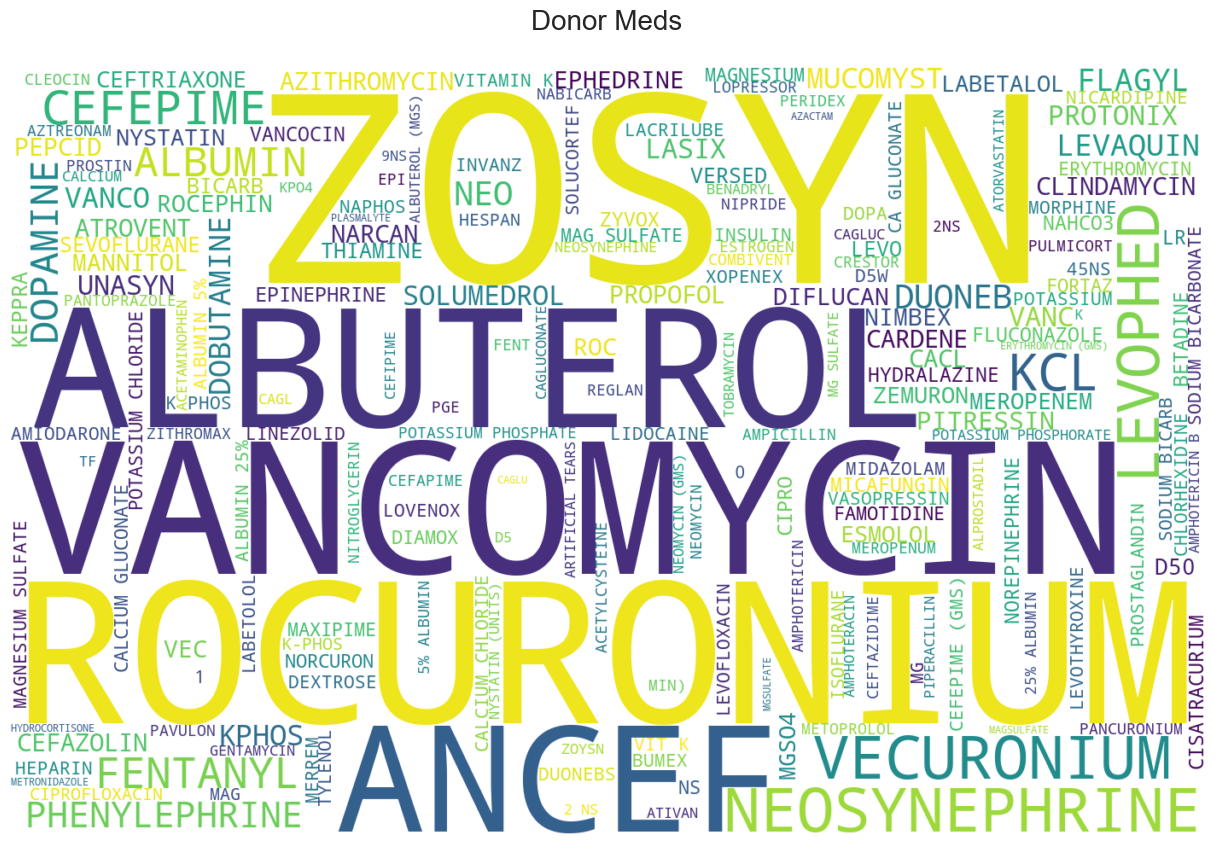

In [9]:
wordcloud = WordCloud(
    width=1400,
    height=900,
    background_color="white"
).generate_from_frequencies(freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.tight_layout(pad=0)
plt.title(f"Donor Meds\n", fontsize=20)
plt.axis("off")
plt.show()


* **Zosyn** (piperacillin/tazobactam) is a powerful, hospital-grade intravenous antibiotic combination used to treat severe bacterial infections, including pneumonia, intra-abdominal infections, and skin infections. It works by combining piperacillin, a penicillin-class antibiotic, with tazobactam, which protects piperacillin from degradation, allowing it to kill bacteria.
* **Vancomycin** is a powerful glycopeptide antibiotic used to treat severe, resistant gram-positive bacterial infections, including MRSA and C. difficile. It works by inhibiting bacterial cell wall synthesis, making it a bactericidal agent. It is administered intravenously for systemic infections and orally for gut-specific infections.
* **Albuterol** is a fast-acting bronchodilator (short-acting beta2-agonist) used to open airways in the lungs, commonly known as a "rescue inhaler" for asthma and COPD. It treats wheezing and breathing difficulties by relaxing airway muscles.
* **Rocuronium** (brand name Zemuron) is an intermediate-acting, nondepolarizing neuromuscular blocking agent (paralytic) used during surgery or critical care. It is administered intravenously as an adjunct to general anesthesia to relax skeletal muscles, facilitating rapid sequence and routine tracheal intubation.
* **Levophed** (norepinephrine bitartrate) is a potent vasopressor medication used in emergency settings to treat severe, acute low blood pressure (hypotension) by rapidly constricting blood vessels and increasing blood pressure. It is administered via intravenous (IV) infusion in critical care, often in conditions like septic shock
* **Neo-Synephrine** (phenylephrine) is a medication used primarily as a nasal decongestant to temporarily relieve a stuffy nose and sinus pressure from colds, allergies, and hay fever. It works as a vasoconstrictor, narrowing blood vessels in the nasal passages to reduce swelling and improve breathing.
* **KCl** (Potassium chloride) is an electrolyte supplement used to prevent or treat low blood potassium levels (hypokalemia), often caused by diuretics or illnesses. It supports heart, muscle, and nerve function, available as oral tablets/powders or IV.
* **Ancef (cefazolin)** is a first-generation cephalosporin antibiotic used to treat various bacterial infections—including skin, bone, joint, and urinary tract infections—and is commonly given intravenously before surgery to prevent infections. It works by inhibiting bacterial cell wall synthesis.
* **Vecuronium** (brand name: Norcuron) is a non-depolarizing neuromuscular blocking agent used to produce skeletal muscle relaxation during surgery, tracheal intubation, or mechanical ventilation. It works by blocking nerve signals to muscles, resulting in temporary paralysis, but it does not cause sedation.
* **Albumin** (human) injection is a sterile, liquid protein solution derived from human plasma used to treat low blood volume (hypovolemia), shock, and low albumin levels (hypoalbuminemia). It increases blood pressure and plasma volume while reducing fluid leakage into tissues (edema); it is commonly used in critical care, major surgeries, burns, and liver disease.

#### OtherMedsText1_DON	& OtherMedsText2_DON & OtherMedsText3_DON

In [10]:
# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r"[^,]+",   # treat each med as a token
    lowercase=False
)

# used in clustering
X_meds = tfidf.fit_transform(df["Meds_DON"])

In [11]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

In [12]:
u.any_nans(df)

--- Missing Values Found (Total Rows: 28,326) ---
                                Count Percentage
IschemicTimeHour_DON              188    0.6637%
LungPO2_FIO2_DON                  171    0.6037%
LungPO2_DON                        93    0.3283%
OrganRecovery_PCO2_DON             82    0.2895%
BloodPH_DON                        76    0.2683%
Level_SGOT_AST_DON                 57    0.2012%
Level_SGOT_ALT_DON                 57    0.2012%
TerminalTotalBilirubin_DON         56    0.1977%
BloodUreaNitrogenLevel_DON         52    0.1836%
Creatinine_DON                     52    0.1836%
Hematocrit_DON                     52    0.1836%
LV_EjectionFractionPercent_DON     31    0.1094%
WeightKg_DON                        3    0.0106%


#### IschemicTimeHour_DON

In [13]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()


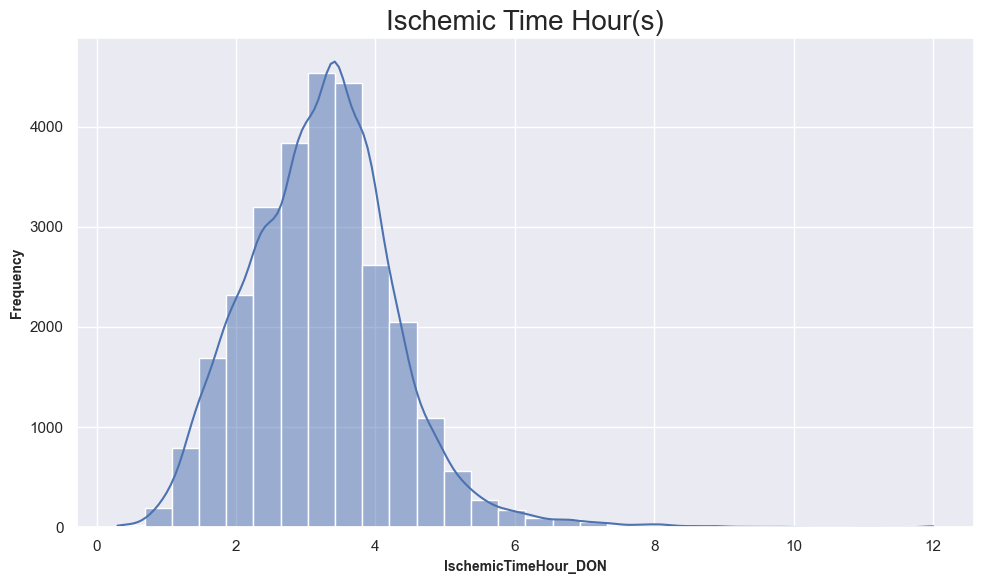

In [14]:
plot_histogram(df, 'IschemicTimeHour_DON', txt='Ischemic Time Hour(s)', bins=30)

In [15]:
df.IschemicTimeHour_DON.unique()

array([ 4.9,  3.1,  1.4,  3.5,  2.8,  3.8,  3.9,  3.3,  2.4,  3. ,  1.3,
        1.8,  4. ,  3.6,  2.9,  2.6,  4.2,  2. ,  4.5,  3.7,  4.3,  5.3,
        4.6,  5.1,  1.2,  1.6,  2.2,  nan,  2.3,  2.7,  3.4,  2.1,  1.9,
        2.5,  1.5,  3.2,  4.1,  4.8,  4.4,  1.7,  7. ,  5.2,  5. ,  6. ,
        1.1,  7.3,  5.8,  0.8,  5.7,  5.4,  4.7,  0.7,  6.7,  0.4,  1. ,
        5.6,  6.1,  7.4,  0.9,  6.2,  5.9,  6.4,  6.6,  5.5,  6.8,  7.7,
        6.3,  7.2,  7.9,  0.3,  0.5,  6.5,  8.3,  7.1,  8.1,  8.8,  7.8,
        6.9,  8.9,  8.2,  8.6,  8.5, 10. ,  8. , 12. ,  9.3,  0.6,  9. ,
       11. ,  7.5,  7.6,  9.7,  9.8,  8.7,  9.2,  9.5])

In [16]:
u.check_informative_missingness(df, 'IschemicTimeHour_DON')

--- IschemicTimeHour_DON ---
n: (Unknown=188, Known=28,138)
Mean survival: (Unknown=1,022.5d, Known=1,332.2d)
Difference: -309.7 days
ρ-Value: 0.0002
RESULT: Statistically Significant (Informative Missingness) consistent with MAR or MNAR



In [17]:
# convert to ordinal
new_nan = df.IschemicTimeHour_DON.max() + 1
# new null value
df.IschemicTimeHour_DON = df.IschemicTimeHour_DON.fillna(13.0)
# Define the order
logical_order = df.IschemicTimeHour_DON.tolist()
# remove dups & sort
logical_order = sorted(set(logical_order))
# convert to list
logical_order = list(logical_order)
# Create the "Type" definition
cat_type = CategoricalDtype(categories=logical_order, ordered=True)
# Apply it directly to the column
# Note: Any value NOT in logical_order (like "Unknown") will become NaN
df['IschemicTimeHour_DON'] = df['IschemicTimeHour_DON'].astype(cat_type)
#
u.get_feature_info(df, 'IschemicTimeHour_DON', cat=True)

                        count  unique  top    freq
IschemicTimeHour_DON  28326.0    96.0  3.3  1342.0

:::: NaN Count:
IschemicTimeHour_DON    0 

--- IschemicTimeHour_DON ---
dtype: category
Categories: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.5, 8.6, 8.7, 8.8, 8.9, 9.0, 9.2, 9.3, 9.5, 9.7, 9.8, 10.0, 11.0, 12.0, 13.0]
Ordered: True



In [20]:
# info
u.get_feature_info(df, 'LungPO2', cat=False)

                    count unique      top   freq        mean         std   min    25%    50%    75%    max
LungPO2_DON       28233.0    NaN      NaN    NaN  280.882815  159.598733  7.38  131.0  257.0  425.0  698.0
LungPO2_Done_DON    28326      3  Missing  19600         NaN         NaN   NaN    NaN    NaN    NaN    NaN
LungPO2_FIO2_DON  28155.0    NaN      NaN    NaN   82.129639   25.546757   1.0   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON          93
LungPO2_Done_DON      0
LungPO2_FIO2_DON    171 



In [42]:
import importlib
importlib.reload(u)

<module 'utilities' from '/Users/sir/Desktop/Project/UNOS/Notebook/../Src/utilities.py'>

In [13]:
# from scipy.sparse import hstack

# X = hstack([X_cat, X_meds])

In [ ]:


tfidf = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"[A-Za-z0-9\-/\+%]+",
    lowercase=False
)

tfidf_matrix = tfidf.fit_transform(df["Meds_Doc"])
